In [33]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

print("Pandas version:", pd.__version__)

Pandas version: 3.0.1


In [ ]:
# Load the dataset
df = pd.read_csv("/Users/riki/Documents/applied-ml-classic/data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [9]:
#check first 5 rows
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [10]:
#Row and collumns dataset
print(f"Shape dataset: {df.shape}")

Shape dataset: (7043, 21)


In [11]:
#check for memory usage, null count and dtype each column
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [15]:
# statistic for mean, min, max
display(df.describe())

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [18]:
display(df.describe(include=['O']))

/var/folders/f1/df8mrxcs5n9fz7hj5fhm9xx40000gn/T/ipykernel_2650/2952477715.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  display(df.describe(include=['O']))


,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,7590-VHVEG,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,20.2,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


# summary of data inspection :
1. total row is around 7k with 21 column
2. All row is safe from null value, no null value found
3. Total charge is number, need to change Dtypes to float64. Precaution: handle potential empty strings during conversion.
4. Skewness Strategy: > * tenure (Right Skew) and MonthlyCharges (Left Skew) show mild skewness.

Since we plan to use Tree-based models, no transformation is required as they are invariant to monotonic transformations.

For Logistic Regression, we will monitor the performance; if the model struggles, we might reconsider Scaling or Power Transformation later.

Next we focus on checking missing value and duplicates, in preparation for cleaning engineering

In [ ]:
# check for null/nan in each column
missing_data = df.isnull().sum()
print(f"missing data:\n{missing_data}")

missing data:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64 


In [35]:
# check missing data percentage
missing_percentage = (df.isnull().sum() / len(df)) * 100
print(f"percentage missing value : \n{missing_percentage} ")

percentage missing value : 
customerID          0.0
gender              0.0
SeniorCitizen       0.0
Partner             0.0
Dependents          0.0
tenure              0.0
PhoneService        0.0
MultipleLines       0.0
InternetService     0.0
OnlineSecurity      0.0
OnlineBackup        0.0
DeviceProtection    0.0
TechSupport         0.0
StreamingTV         0.0
StreamingMovies     0.0
Contract            0.0
PaperlessBilling    0.0
PaymentMethod       0.0
MonthlyCharges      0.0
TotalCharges        0.0
Churn               0.0
dtype: float64 


In [28]:
# check duplicated data
print(f"Duplicated row : {df.duplicated().sum()}")

Duplicated row : 0


# conclusion
No missing value or duplicate

# Univariate Analysis

In [95]:
# Check data variation
# Convert TotalCharges to int (kalau ada spasi/error, coerce ke NaN—tapi missing 0, aman)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# divid number and text column and remove customer
categorical_cols = df.select_dtypes(include=['object','category']).columns.drop('customerID', errors='ignore').tolist()

numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("Categorical cols:", categorical_cols)
print("Numerical cols:", numerical_cols)

Categorical cols: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']
Numerical cols: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


/var/folders/f1/df8mrxcs5n9fz7hj5fhm9xx40000gn/T/ipykernel_2650/3605978144.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object','category']).columns.drop('customerID', errors='ignore').tolist()


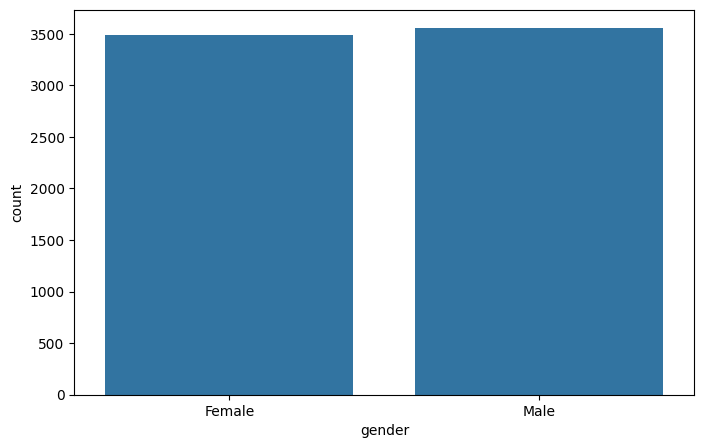

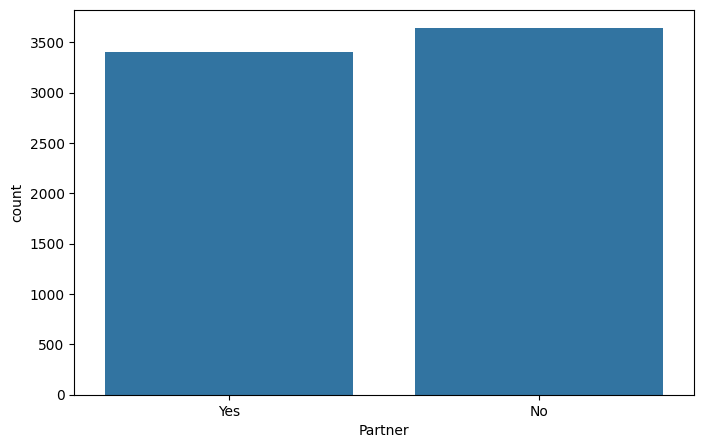

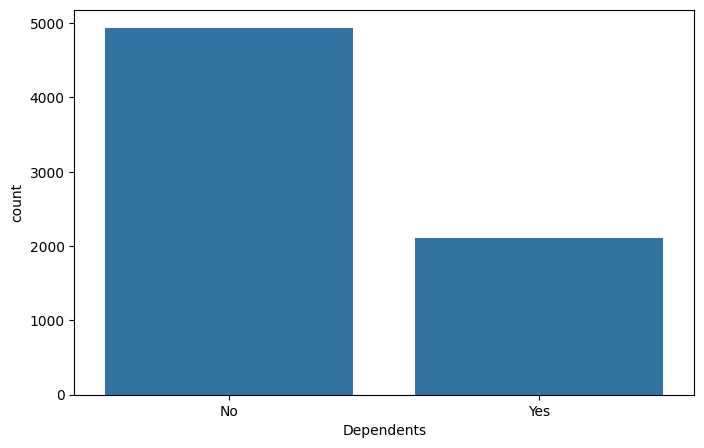

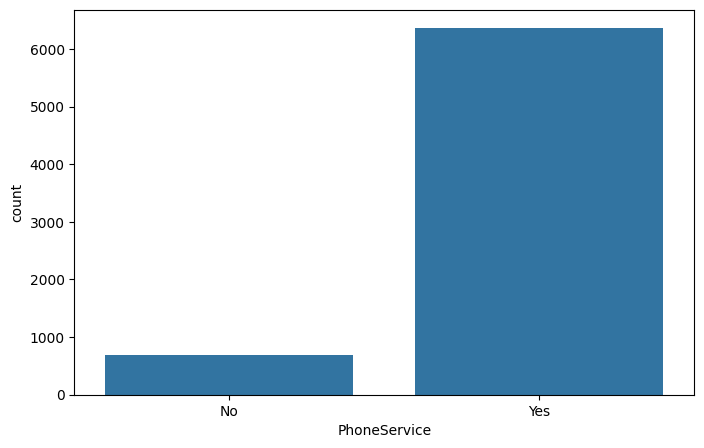

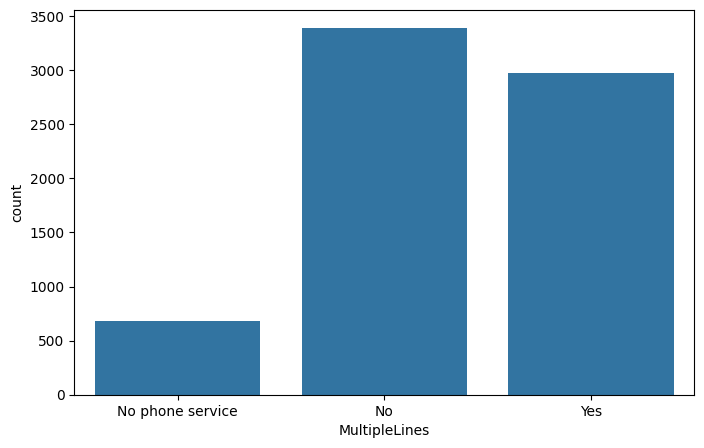

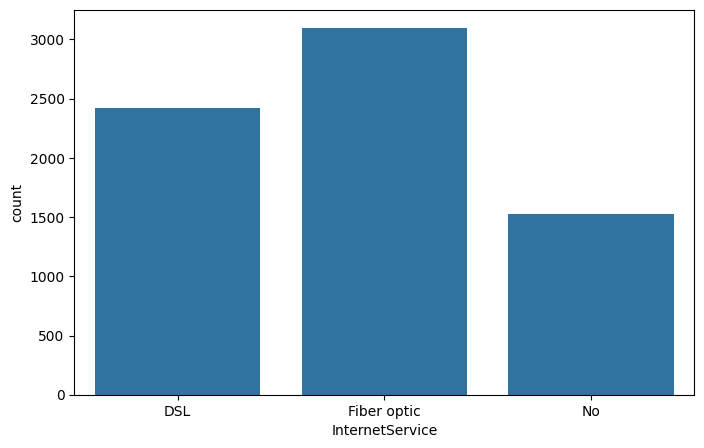

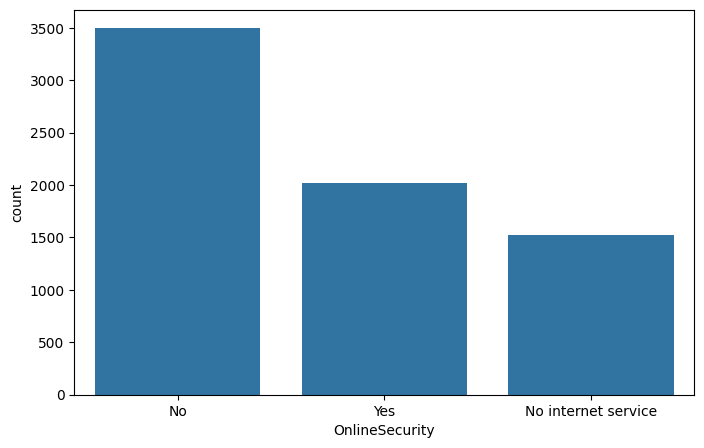

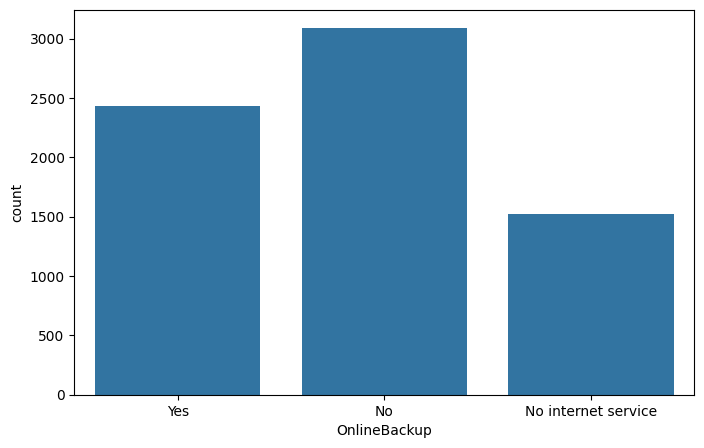

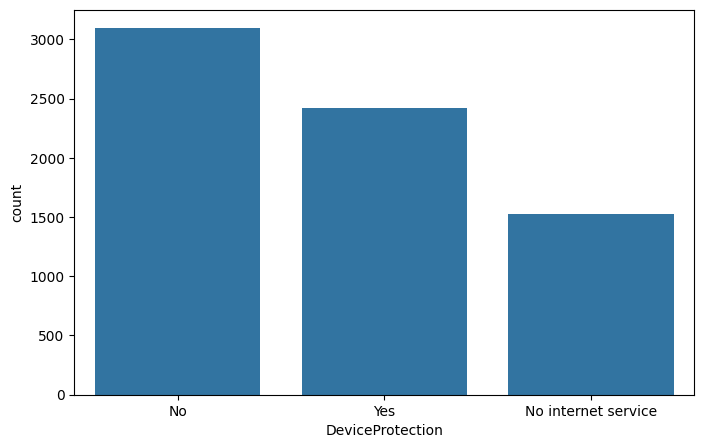

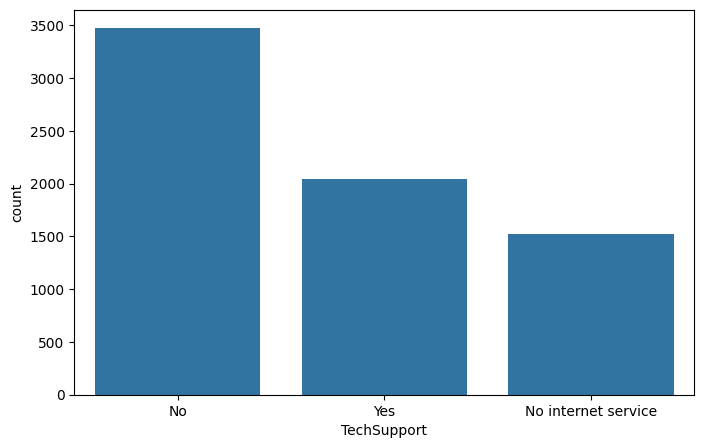

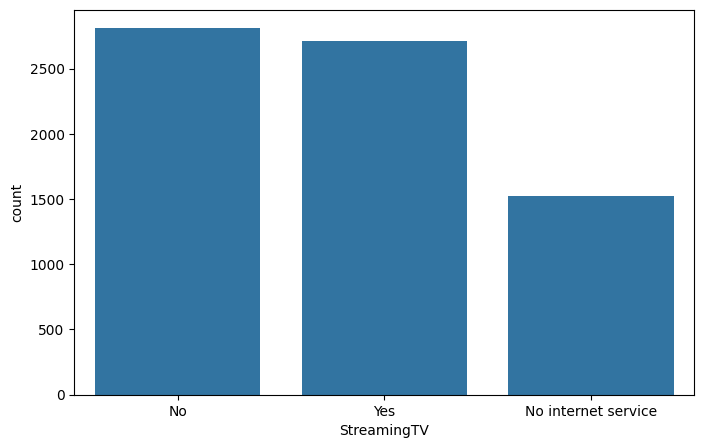

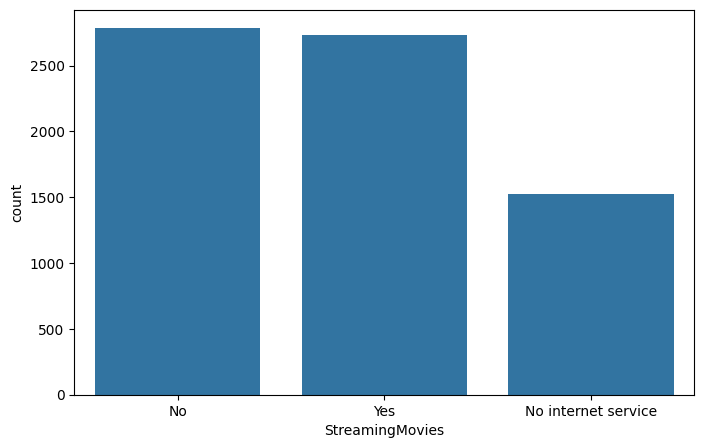

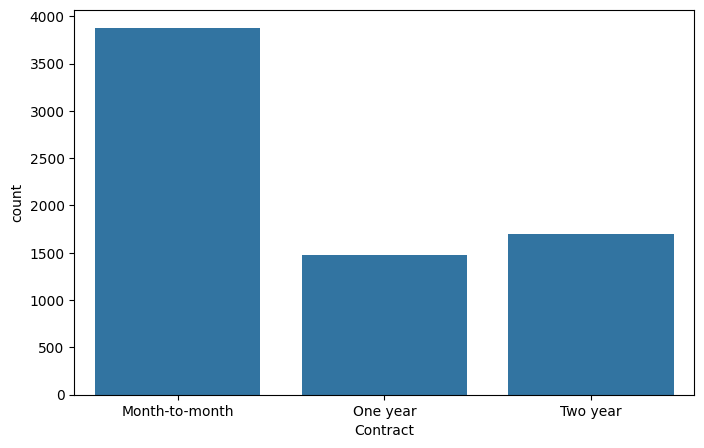

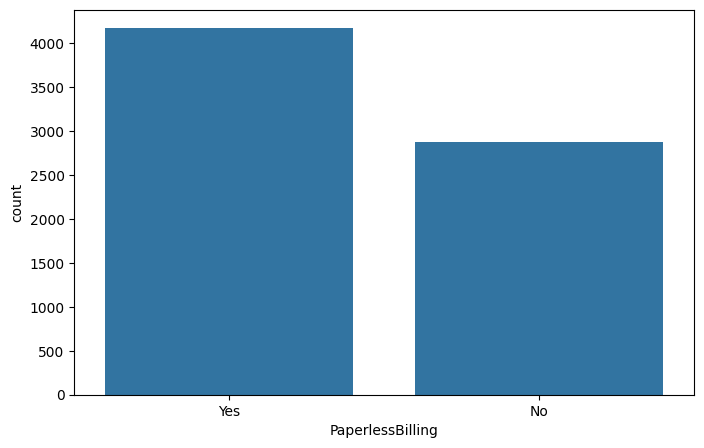

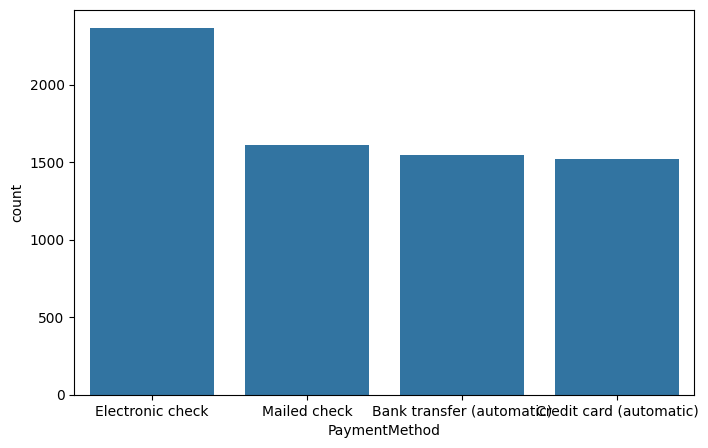

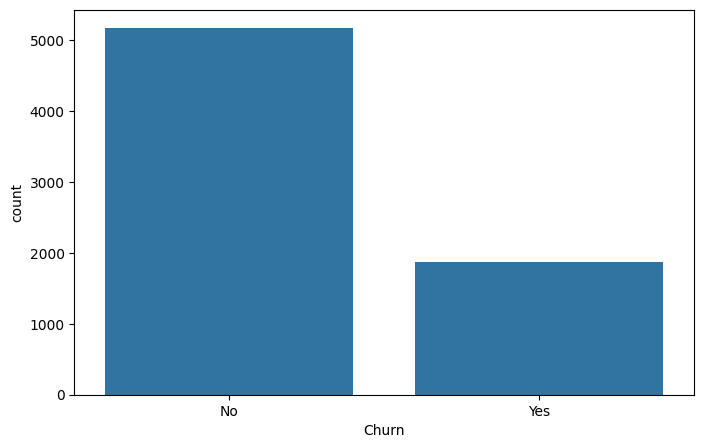

In [99]:
# Univariate Categorical
for col in categorical_cols:
  
    plt.figure(figsize=(8,5))
    sns.countplot(data=df, x=col)
    plt.show()

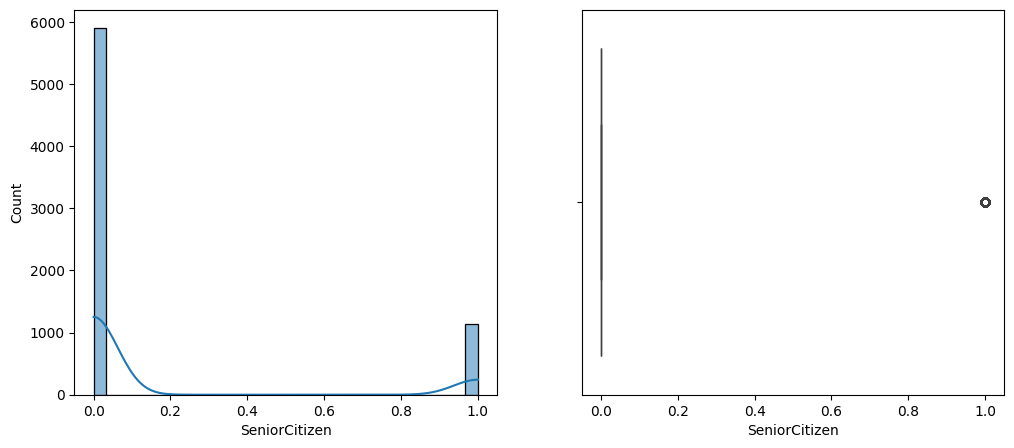

SeniorCitizen - Skewness: 1.83, Kurtosis: 1.36


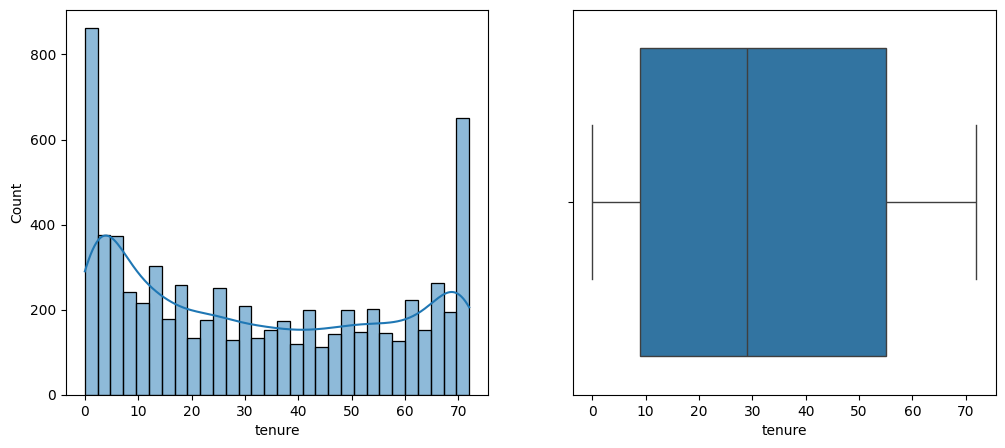

tenure - Skewness: 0.24, Kurtosis: -1.39


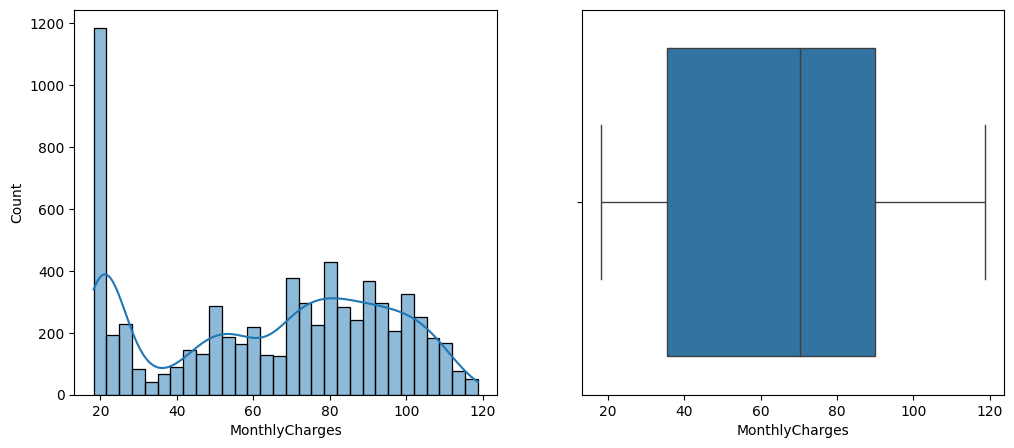

MonthlyCharges - Skewness: -0.22, Kurtosis: -1.26


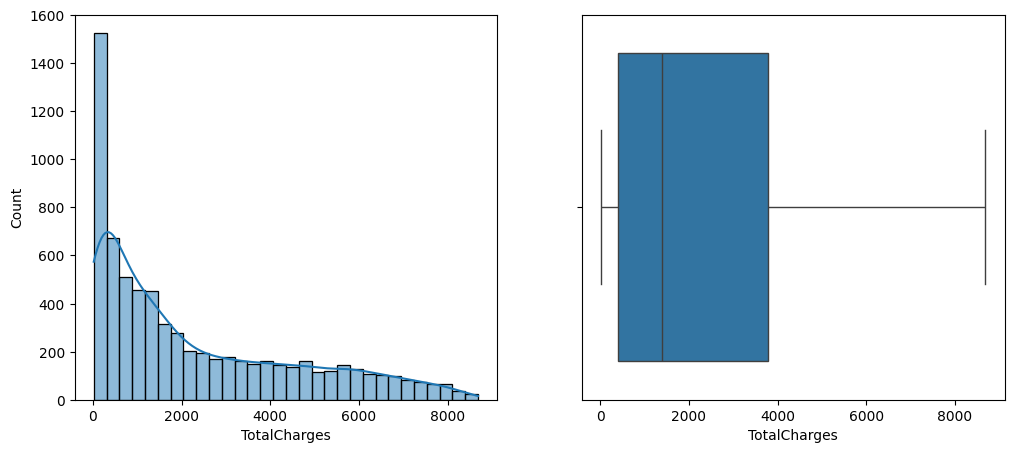

TotalCharges - Skewness: 0.96, Kurtosis: -0.23


In [ ]:
# Univariate Number
for col in numerical_cols:
    plt.figure(figsize=(12, 5))
    
    # Histogram + KDE
    plt.subplot(1, 2, 1)
    sns.histplot(df[col], bins=30, kde=True)b
    
    # Boxplot untuk outlier
    plt.subplot(1, 2, 2)
    sns.boxplot(x=df[col])
    
    plt.show()
    
    # Bonus stats: Check skewness and kurtosis
    print(f"{col} - Skewness: {df[col].skew():.2f}, Kurtosis: {df[col].kurt():.2f}")

# summary of data inspection :
1. Target (Churn) is moderately imbalanced.
PhoneService is dominated by one category.
2. No significant outliers detected using boxplot/IQR inspection.
3. Most numeric features show positive (right) skewness,
especially TotalCharges and tenure.

# implication :
1. Use stratified train-test split to preserve class distribution.
Consider class_weight or imbalance-aware metrics (F1, ROC-AUC).
PhoneService may provide limited predictive power due to low variance.
2. Outlier clipping or winsorization is not required.
Standard preprocessing should be sufficient.
3. Consider log1p transformation to reduce skewness.
Tree-based models may not require transformation,
but linear or distance-based models can benefit.